# First data exploration

This notebook contains the code to explore various datasets for the RSApp project.

Datasets include:
- a fire history (nr fires per year per pixel) image, with a raster for each year from 2001 to 2015, provided by [Global Forest Watch](https://data.globalforestwatch.org/datasets/indonesia-fire-history/about)
- MODIS fire alerts in Indonesia from 2001 to 2025, from NASA FIRMS
- shapefile of peatland areas from Global Forest Watch (not good according to Sasa) - maybe compare to PEATMAP and Global Peat Map
- 2021 global land cover map from ESA, cropped to Indonesia for classification into cropland vs. forest vs. shrubland

# Wildfire history Indonesia

In [35]:
import rasterio
import xarray as xr
import numpy as np
from rasterio.plot import show

In [38]:
import rioxarray

### Explore single raster (2001)

In [3]:
path = "fire-history-data/kd2001_rgb.tif"
fh_2001 = rasterio.open(path)

In [15]:
# Basic info on the raster dataset
print("Number of bands:", fh_2001.count)
print("Width (nr of pixels):", fh_2001.width)
print("Height (nr of pixels):", fh_2001.height)
print("CRS:", fh_2001.crs)
print("Bounding coordinates:", fh_2001.bounds)

Number of bands: 3
Width (nr of pixels): 9133
Height (nr of pixels): 3306
CRS: EPSG:4326
Bounding coordinates: BoundingBox(left=95.3435, bottom=-10.7195, right=141.0085, top=5.810500000000001)


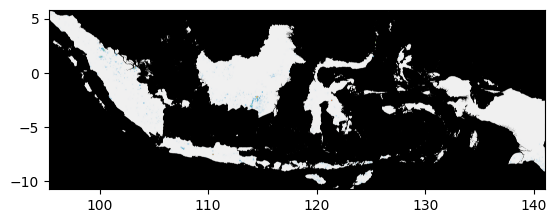

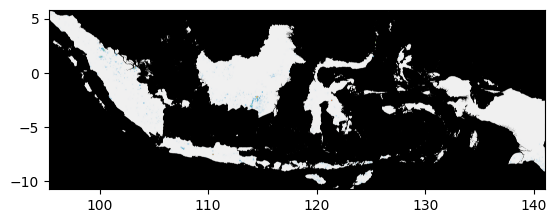

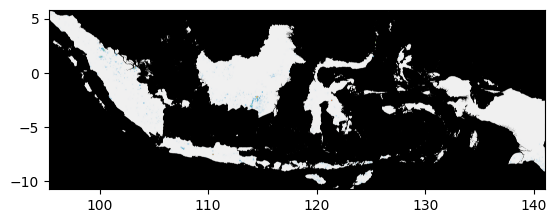

<Axes: >

In [20]:
# Display individual layers
show(fh_2001,1)
show(fh_2001,2)
show(fh_2001,3)

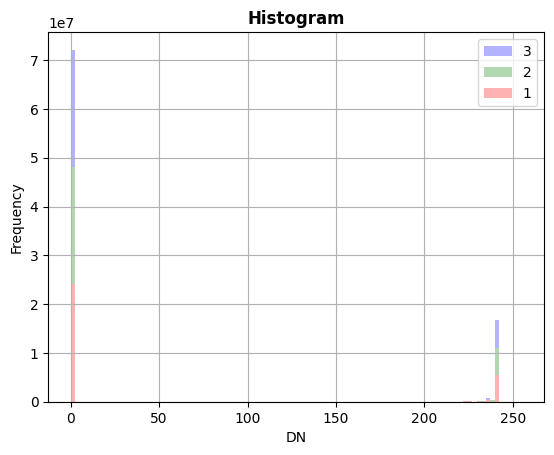

In [49]:
from rasterio.plot import show_hist

show_hist(fh_2001, 
          bins=100,
          lw=0.0, 
          stacked=True, 
          alpha=0.3,
          histtype='stepfilled', 
          title="Histogram")

In [53]:
print(np.unique(fh_2001.read(1)))

print(np.unique(fh_2001.read(2)))

print(np.unique(fh_2001.read(3)))


[  0  56  59  63  66  68  71  74  79  80  88  90  94  96  97 102 103 106
 109 111 115 118 121 123 125 127 132 133 138 141 144 146 147 151 153 157
 159 161 163 165 166 170 171 172 177 179 181 184 186 189 190 193 197 202
 206 210 211 214 216 219 223 225 227 230 231 234 237 239 240 241 242 245
 247 250 252 255]
[  0  27  29  31  37  39  42  48  50  52  55  60  62  64  67  71  73  75
  77  79  81  82  84  86  92  94  95  97  99 101 103 106 108 110 113 118
 124 129 132 134 139 145 147 152 153 160 161 162 163 164 166 167 168 169
 172 173 174 175 178 180 181 184 185 186 189 190 191 192 193 194 196 197
 199 201 202 203 204 205 206 207 209 211 212 214 217 218 219 222 223 224
 226 227 228 230 231 232 233 234 235 237 239 240 242 245 247 250]
[  0   7  10  12  15  17  19  22  24  27  29  32  34  37  39  40  42  45
  47  49  52  55  57  60  62  63  66  68  71  73  77  79  82  84  87  89
  91  92  93  96  98 100 102 104 105 106 108 109 110 111 113 114 116 117
 119 122 126 127 130 134 137 140 143 146

#### Load all rasters as xarray

In [41]:
def load_yearly_rasters_rio(years, path_template="fire-history-data/kd{year}_rgb.tif"):
    """
    Load raster layers from different years and combine
    them into xarray object, with full spatial metadata preserved.

    Input:
    -----
    years : list or range
        years to load (e.g., range(2001, 2016))
    path_template : str
        path template with {year} placeholder

    Output:
    ------
    combined: xarray
        combined raster layers (yearly temporal resolution)
    """
    
    datasets = []
    
    for year in years:
        filepath = path_template.format(year=year)
        da = rioxarray.open_rasterio(filepath, masked=True)
        #da = da.squeeze('band', drop=True)  # Remove band dimension if single band
        da = da.assign_coords(time=year)
        datasets.append(da)
    
    # concatenate along time dimension
    combined = xr.concat(datasets, dim='time')
    return combined

# function developed by Claude AI

In [47]:
fh = load_yearly_rasters_rio(years=range(2001,2003))

In [48]:
fh

<xarray.DataArray (time: 2, band: 3, y: 6602, x: 9771)> Size: 2GB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ...,  0.,  0.,  0.],
         [nan, nan, nan, ...,  0.,  0.,  0.],
         [nan, nan, nan, ...,  0.,  0.,  0.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ...,  0.,  0.,  0.],
         [nan, nan, nan, ...,  0.,  0.,  0.],
         [nan, nan, nan, ...,  0.,  0.,  0.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]],
      shape=(2, 3, 6602, 9771), dtype=float32)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 78kB 95.32 95.32 95.33 95.33 ... 141.0 141.0 141.0
  * y            (y) float64 53kB -10.9 -10.89 -10.89 ... 5.798 5.803 5.808
    spatial_ref  int64 8B 0
  * time         (time) int64 16B 2001 2002
Attributes:
    DataType:       Processed
    AREA_OR_POINT:  Area
    BandName:       Band_1
    scale_factor:   1.0
    add_offset:     0.0

In [44]:
rioxarray.open_rasterio("fire-history-data/kd2001_rgb.tif", masked=True)

<xarray.DataArray (band: 3, y: 3306, x: 9133)> Size: 362MB
[90581094 values with dtype=float32]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 73kB 95.35 95.35 95.36 95.36 ... 141.0 141.0 141.0
  * y            (y) float64 26kB 5.808 5.803 5.798 ... -10.71 -10.71 -10.72
    spatial_ref  int64 8B 0
Attributes:
    DataType:       Processed
    AREA_OR_POINT:  Area
    BandName:       Band_1
    scale_factor:   1.0
    add_offset:     0.0

# MODIS fire alerts from NASA FIRMS
Indonesia, 2001 to 2025

attribute documentation [here](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs)

In [59]:
import geopandas as gpd

In [56]:
modis_fa_path = "nasa-firms-modis-fire-alerts/fire_archive_M-C61_697841.shp"

In [60]:
modis_fa = gpd.read_file(modis_fa_path)

In [64]:
# TYPE 0: presumed vegetation fire
modis_fa_vf = modis_fa[modis_fa["TYPE"] == 0]

In [80]:
modis_fa_vf.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,year,YEAR
0,-4.0082,121.7859,312.0,2.3,1.5,2001-01-01,0258,Terra,MODIS,57,6.03,291.7,22.9,D,0,POINT (121.7859 -4.0082),"[2001, 01-01]",2001
1,-8.4164,117.5434,320.0,1.3,1.1,2001-01-01,0259,Terra,MODIS,39,6.03,305.8,13.1,D,0,POINT (117.5434 -8.4164),"[2001, 01-01]",2001
5,-8.8759,120.7638,314.9,2.6,1.6,2001-01-02,0204,Terra,MODIS,0,6.03,296.0,28.8,D,0,POINT (120.7638 -8.8759),"[2001, 01-02]",2001
8,-8.2273,123.8952,312.5,2.2,1.4,2001-01-03,0247,Terra,MODIS,0,6.03,286.4,17.1,D,0,POINT (123.8952 -8.2273),"[2001, 01-03]",2001
13,0.0546,101.7350,312.4,1.5,1.2,2001-01-05,0411,Terra,MODIS,60,6.03,284.5,12.7,D,0,POINT (101.735 0.0546),"[2001, 01-05]",2001


In [78]:
# add column with year
modis_fa_vf["YEAR"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=1).str[0]

<Axes: >

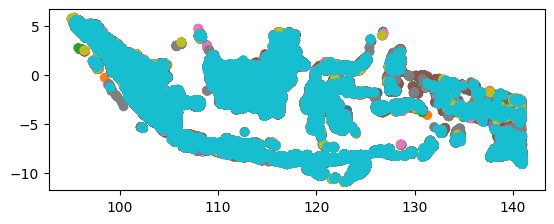

In [79]:
modis_fa_vf.plot(column="YEAR")

# Indonesian peat lands

In [82]:
filepath_peatlands = "indonesia-peatlands/Indonesia_Peat_Lands.shp"
peatlands = gpd.read_file(filepath_peatlands)

In [83]:
peatlands.head()

,objectid_1,objectid,layer_revi,shape_leng,globalid,shape_Le_1,shape_Area,geometry
0,1,482,gambut,70789.064321,{DF27C432-2805-4FCF-8A7E-7E1DFD125C87},72528.694951,3.286301e+07,"MULTIPOLYGON Z (((14845286.338 -394955.138 0, ..."
1,2,483,gambut,3013.842302,{03DD8438-E728-49A1-9DEB-5997D38E1657},2996.905854,5.275723e+05,"POLYGON Z ((14893124.535 -393987.592 0, 148928..."
2,3,484,gambut,5750.073144,{356A5BD6-C249-4485-BB25-C99B383A708C},5635.047284,1.321287e+06,"POLYGON Z ((14797350.914 -393724.104 0, 147973..."
3,4,485,gambut,2027.459326,{0159915D-83EB-4B7C-AF71-AA67029CB67E},1912.760954,8.390727e+04,"POLYGON Z ((14891358.237 -393201.229 0, 148914..."
4,5,486,gambut,178017.496343,{82E80B91-9343-44BE-B9D5-119AD8FAE5C9},176121.923929,2.474371e+08,"POLYGON Z ((15554582.332 -395133.063 0, 155547..."


<Axes: >

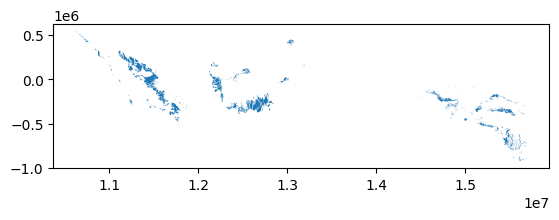

In [84]:
peatlands.plot(column="layer_revi")